## 1. Import Libraries

In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Machine Learning - Models
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Machine Learning - Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 2. Load and Explore Data

In [2]:
# Load dataset
df = pd.read_csv('APY.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head(10)

Dataset Shape: (345336, 8)

Columns: ['State', 'District ', 'Crop', 'Crop_Year', 'Season', 'Area ', 'Production', 'Yield']

First few rows:


,State,District,Crop,Crop_Year,Season,Area,Production,Yield
0,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Kharif,2439.6,3415.0,1.40
1,Andaman and Nicobar Island,NICOBARS,Arecanut,2007,Rabi,1626.4,2277.0,1.40
2,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Autumn,4147.0,3060.0,0.74
3,Andaman and Nicobar Island,NICOBARS,Arecanut,2008,Summer,4147.0,2660.0,0.64
4,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Autumn,4153.0,3120.0,0.75
5,Andaman and Nicobar Island,NICOBARS,Arecanut,2009,Summer,4153.0,2080.0,0.50
6,Andaman and Nicobar Island,NICOBARS,Arecanut,2000,Kharif,1254.0,2000.0,1.59
7,Andaman and Nicobar Island,NICOBARS,Arecanut,2001,Kharif,1254.0,2061.0,1.64
8,Andaman and Nicobar Island,NICOBARS,Arecanut,2002,Whole Year,1258.0,2083.0,1.66
9,Andaman and Nicobar Island,NICOBARS,Arecanut,2003,Whole Year,1261.0,1525.0,1.21


In [3]:
# Data Info
print("Dataset Information:")
print("="*60)
df.info()

print("\n" + "="*60)
print("Statistical Summary:")
print("="*60)
df.describe()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 345336 entries, 0 to 345335
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   State       345336 non-null  object 
 1   District    345336 non-null  object 
 2   Crop        345327 non-null  object 
 3   Crop_Year   345336 non-null  int64  
 4   Season      345336 non-null  object 
 5   Area        345336 non-null  float64
 6   Production  340388 non-null  float64
 7   Yield       345336 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 21.1+ MB

Statistical Summary:


,Crop_Year,Area,Production,Yield
count,345336.000000,3.453360e+05,3.403880e+05,345336.000000
mean,2008.887512,1.167147e+04,9.584726e+05,79.423135
std,6.564361,4.584079e+04,2.153068e+07,916.678396
min,1997.000000,4.000000e-03,0.000000e+00,0.000000
25%,2003.000000,7.400000e+01,8.700000e+01,0.550000
50%,2009.000000,5.320000e+02,7.170000e+02,1.000000
75%,2015.000000,4.112000e+03,7.182000e+03,2.470000
max,2020.000000,8.580100e+06,1.597800e+09,43958.330000


In [4]:
# Check missing values
print("Missing Values:")
print("="*60)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
})
missing_df = missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
print(missing_df)

Missing Values:
            Missing_Count  Percentage
Production           4948    1.432807
Crop                    9    0.002606


In [5]:
# Check unique values in categorical columns
print("Unique Values in Categorical Columns:")
print("="*60)
for col in ['State', 'District ', 'Crop', 'Season']:
    if col in df.columns:
        print(f"\n{col}: {df[col].nunique()} unique values")
        if df[col].nunique() <= 20:
            print(df[col].value_counts())

Unique Values in Categorical Columns:

State: 37 unique values

District : 707 unique values

Crop: 55 unique values

Season: 6 unique values
Season
Kharif         138369
Rabi           100951
Whole Year      68680
Summer          22098
Winter           8249
Autumn           6989
Name: count, dtype: int64


## 3. Data Preprocessing

In [6]:
# Create a copy for preprocessing
df_processed = df.copy()

# Clean column names (remove trailing spaces)
df_processed.columns = df_processed.columns.str.strip()

print("Cleaned column names:")
print(df_processed.columns.tolist())

Cleaned column names:
['State', 'District', 'Crop', 'Crop_Year', 'Season', 'Area', 'Production', 'Yield']


In [7]:
# Handle missing values in target variable (Yield)
print(f"Rows before removing missing Yield: {len(df_processed)}")
df_processed = df_processed.dropna(subset=['Yield'])
print(f"Rows after removing missing Yield: {len(df_processed)}")

# Remove rows where Yield is 0 or negative (invalid data)
df_processed = df_processed[df_processed['Yield'] > 0]
print(f"Rows after removing zero/negative Yield: {len(df_processed)}")

Rows before removing missing Yield: 345336
Rows after removing missing Yield: 345336
Rows after removing zero/negative Yield: 339240


In [8]:
# Handle missing values in Production and Area
# Impute with median values
imputer = SimpleImputer(strategy='median')
df_processed[['Area', 'Production']] = imputer.fit_transform(df_processed[['Area', 'Production']])

print("Missing values after imputation:")
print(df_processed.isnull().sum())

Missing values after imputation:
State         0
District      0
Crop          4
Crop_Year     0
Season        0
Area          0
Production    0
Yield         0
dtype: int64


In [9]:
# Remove outliers using IQR method for Yield
Q1 = df_processed['Yield'].quantile(0.25)
Q3 = df_processed['Yield'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 3 * IQR  # Using 3*IQR for less aggressive outlier removal
upper_bound = Q3 + 3 * IQR

print(f"Yield bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Rows before outlier removal: {len(df_processed)}")

df_processed = df_processed[(df_processed['Yield'] >= lower_bound) & (df_processed['Yield'] <= upper_bound)]

print(f"Rows after outlier removal: {len(df_processed)}")

Yield bounds: [-5.25, 8.33]
Rows before outlier removal: 339240
Rows after outlier removal: 298903


## 4. Feature Engineering

In [10]:
# Create new features
df_processed['Production_per_Area'] = df_processed['Production'] / (df_processed['Area'] + 1)  # Adding 1 to avoid division by zero

# Extract decade from Crop_Year
df_processed['Decade'] = (df_processed['Crop_Year'] // 10) * 10

# Year categories
df_processed['Year_Category'] = pd.cut(df_processed['Crop_Year'], 
                                        bins=[1990, 2000, 2010, 2020], 
                                        labels=['1990s', '2000s', '2010s'])

print("New features created:")
print(df_processed[['Production_per_Area', 'Decade', 'Year_Category']].head())

New features created:
   Production_per_Area  Decade Year_Category
0             1.399246    2000         2000s
1             1.399164    2000         2000s
2             0.737705    2000         2000s
3             0.641273    2000         2000s
4             0.751083    2000         2000s


In [11]:
# Encode categorical variables
label_encoders = {}
categorical_cols = ['State', 'District', 'Crop', 'Season', 'Year_Category']

for col in categorical_cols:
    if col in df_processed.columns:
        le = LabelEncoder()
        df_processed[f'{col}_encoded'] = le.fit_transform(df_processed[col].astype(str))
        label_encoders[col] = le
        print(f"Encoded {col}: {df_processed[col].nunique()} unique values")

print("\n✅ All categorical variables encoded!")

Encoded State: 37 unique values
Encoded District: 706 unique values
Encoded Crop: 55 unique values
Encoded Season: 6 unique values
Encoded Year_Category: 3 unique values

✅ All categorical variables encoded!


## 5. Exploratory Data Analysis (EDA)

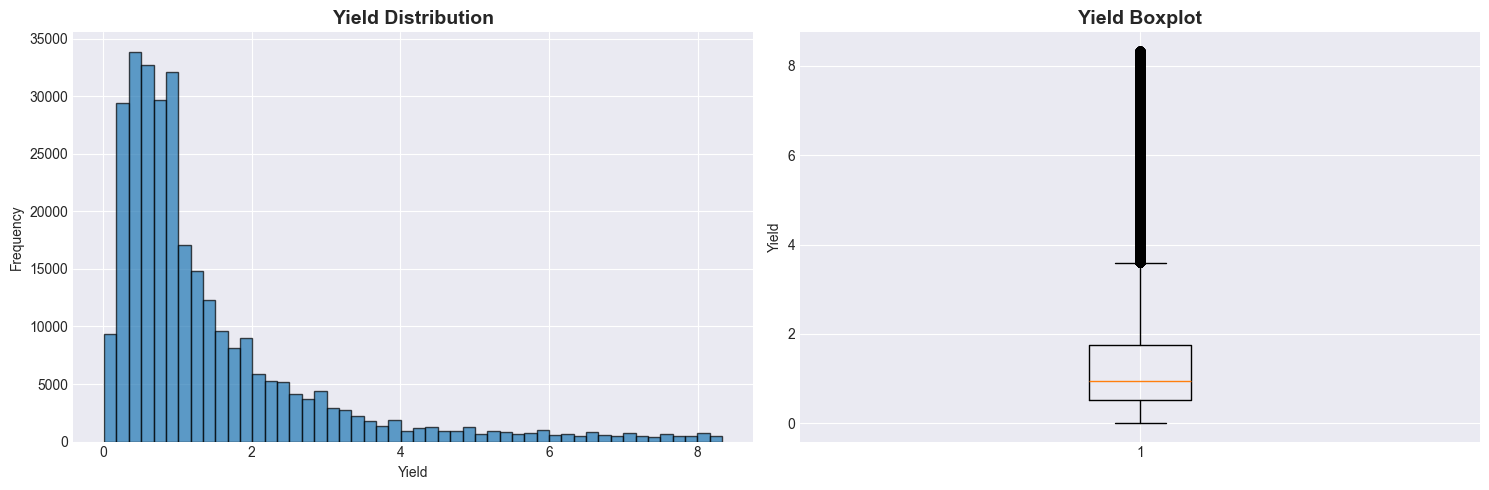

Mean Yield: 1.43
Median Yield: 0.94
Std Dev: 1.46


In [12]:
# Yield distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df_processed['Yield'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Yield Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Yield')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df_processed['Yield'])
axes[1].set_title('Yield Boxplot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Yield')

plt.tight_layout()
plt.show()

print(f"Mean Yield: {df_processed['Yield'].mean():.2f}")
print(f"Median Yield: {df_processed['Yield'].median():.2f}")
print(f"Std Dev: {df_processed['Yield'].std():.2f}")

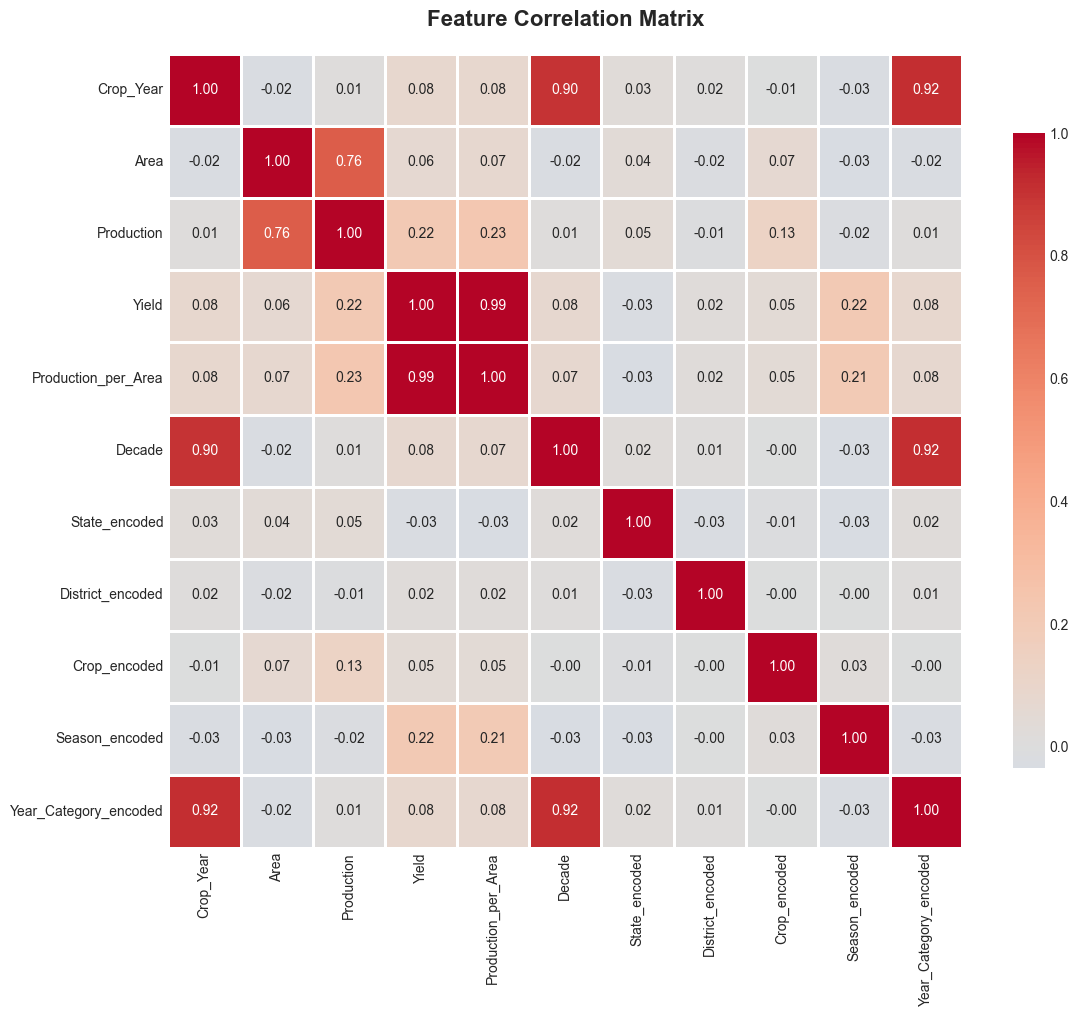

In [13]:
# Correlation heatmap
numeric_cols = ['Crop_Year', 'Area', 'Production', 'Yield', 'Production_per_Area', 'Decade']
encoded_cols = [col for col in df_processed.columns if col.endswith('_encoded')]

correlation_cols = numeric_cols + encoded_cols
correlation_cols = [col for col in correlation_cols if col in df_processed.columns]

plt.figure(figsize=(12, 10))
correlation_matrix = df_processed[correlation_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [14]:
# Top correlations with Yield
yield_correlations = correlation_matrix['Yield'].sort_values(ascending=False)
print("Top Features Correlated with Yield:")
print("="*60)
print(yield_correlations)

Top Features Correlated with Yield:
Yield                    1.000000
Production_per_Area      0.991923
Season_encoded           0.216094
Production               0.215756
Crop_Year                0.084789
Year_Category_encoded    0.079607
Decade                   0.076185
Area                     0.063790
Crop_encoded             0.047278
District_encoded         0.022210
State_encoded           -0.027794
Name: Yield, dtype: float64


## 6. Prepare Data for Modeling

In [15]:
# Select features for modeling
feature_cols = ['Crop_Year', 'Area', 'Production', 'Production_per_Area', 'Decade'] + encoded_cols
feature_cols = [col for col in feature_cols if col in df_processed.columns]

X = df_processed[feature_cols]
y = df_processed['Yield']

print(f"Feature matrix shape: {X.shape}")
print(f"Target variable shape: {y.shape}")
print(f"\nFeatures used: {feature_cols}")

Feature matrix shape: (298903, 10)
Target variable shape: (298903,)

Features used: ['Crop_Year', 'Area', 'Production', 'Production_per_Area', 'Decade', 'State_encoded', 'District_encoded', 'Crop_encoded', 'Season_encoded', 'Year_Category_encoded']


In [16]:
# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

Training set size: 239122 (80.0%)
Testing set size: 59781 (20.0%)


In [17]:
# Feature Scaling (important for Linear models, not for tree-based)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled!")

✅ Features scaled!


## 7. Model Training - XGBoost (Primary Model)

In [18]:
# Train baseline XGBoost model
print("🚀 Training XGBoost Model (Baseline)...\n")

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# Predictions
y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)

# Evaluation
print("XGBoost Baseline Performance:")
print("="*60)
print(f"Training RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.4f}")
print(f"Testing RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_test)):.4f}")
print(f"Training MAE:  {mean_absolute_error(y_train, y_pred_train):.4f}")
print(f"Testing MAE:   {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"Training R²:   {r2_score(y_train, y_pred_train):.4f}")
print(f"Testing R²:    {r2_score(y_test, y_pred_test):.4f}")

print("\n✅ XGBoost baseline model trained!")

🚀 Training XGBoost Model (Baseline)...

XGBoost Baseline Performance:
Training RMSE: 0.0254
Testing RMSE:  0.0276
Training MAE:  0.0108
Testing MAE:   0.0111
Training R²:   0.9997
Testing R²:    0.9996

✅ XGBoost baseline model trained!


## 8. XGBoost Hyperparameter Tuning

In [19]:
# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

print("🔍 Starting Hyperparameter Tuning for XGBoost...")
print(f"Total combinations to test: {np.prod([len(v) for v in param_grid.values()])}")
print("This may take several minutes...\n")

🔍 Starting Hyperparameter Tuning for XGBoost...
Total combinations to test: 729
This may take several minutes...



In [20]:
# Grid Search with Cross-Validation
xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("\n✅ Hyperparameter tuning completed!")
print("\nBest Parameters:")
print("="*60)
for param, value in xgb_grid.best_params_.items():
    print(f"{param}: {value}")

Fitting 5 folds for each of 729 candidates, totalling 3645 fits


KeyboardInterrupt: 

In [ ]:
# Train final XGBoost model with best parameters
xgb_best = xgb_grid.best_estimator_

# Predictions
y_pred_train_best = xgb_best.predict(X_train)
y_pred_test_best = xgb_best.predict(X_test)

# Evaluation
print("\nXGBoost Tuned Model Performance:")
print("="*60)
print(f"Training RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train_best)):.4f}")
print(f"Testing RMSE:  {np.sqrt(mean_squared_error(y_test, y_pred_test_best)):.4f}")
print(f"Training MAE:  {mean_absolute_error(y_train, y_pred_train_best):.4f}")
print(f"Testing MAE:   {mean_absolute_error(y_test, y_pred_test_best):.4f}")
print(f"Training R²:   {r2_score(y_train, y_pred_train_best):.4f}")
print(f"Testing R²:    {r2_score(y_test, y_pred_test_best):.4f}")
print(f"Testing MAPE:  {mean_absolute_percentage_error(y_test, y_pred_test_best)*100:.2f}%")

## 9. Comparison Models (for Representational Purposes)

In [ ]:
# Initialize comparison models
models = {
    'XGBoost (Tuned)': xgb_best,
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1)
}

print("Training comparison models...\n")

In [ ]:
# Train and evaluate all models
results = []

for name, model in models.items():
    print(f"Training {name}...")
    
    # Use scaled data for linear models, original for tree-based
    if 'Regression' in name:
        if name != 'XGBoost (Tuned)':
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
        else:
            y_pred = y_pred_test_best
    else:
        if name != 'XGBoost (Tuned)':
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
        else:
            y_pred = y_pred_test_best
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    
    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2,
        'MAPE (%)': mape
    })

# Create results dataframe
results_df = pd.DataFrame(results).sort_values('RMSE')

print("\n" + "="*80)
print("MODEL COMPARISON RESULTS")
print("="*80)
print(results_df.to_string(index=False))
print("="*80)

## 10. Cross-Validation Analysis

In [ ]:
# Perform K-Fold Cross-Validation on XGBoost
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(xgb_best, X, y, cv=kfold, 
                             scoring='neg_mean_squared_error', n_jobs=-1)

cv_rmse = np.sqrt(-cv_scores)

print("5-Fold Cross-Validation Results (XGBoost):")
print("="*60)
for i, score in enumerate(cv_rmse, 1):
    print(f"Fold {i}: RMSE = {score:.4f}")
print("="*60)
print(f"Mean RMSE: {cv_rmse.mean():.4f}")
print(f"Std Dev:   {cv_rmse.std():.4f}")

## 11. Feature Importance Analysis

In [ ]:
# Get feature importances from XGBoost
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_best.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 8))
plt.barh(feature_importance['Feature'][:15], feature_importance['Importance'][:15])
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Top 15 Feature Importances (XGBoost)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 Most Important Features:")
print("="*60)
print(feature_importance.head(10).to_string(index=False))

## 12. Model Comparison Visualization

In [ ]:
# Create comparison charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# RMSE comparison
axes[0, 0].barh(results_df['Model'], results_df['RMSE'], color='skyblue')
axes[0, 0].set_xlabel('RMSE (Lower is Better)', fontsize=11)
axes[0, 0].set_title('RMSE Comparison', fontsize=13, fontweight='bold')
axes[0, 0].invert_yaxis()

# MAE comparison
axes[0, 1].barh(results_df['Model'], results_df['MAE'], color='lightcoral')
axes[0, 1].set_xlabel('MAE (Lower is Better)', fontsize=11)
axes[0, 1].set_title('MAE Comparison', fontsize=13, fontweight='bold')
axes[0, 1].invert_yaxis()

# R² comparison
axes[1, 0].barh(results_df['Model'], results_df['R²'], color='lightgreen')
axes[1, 0].set_xlabel('R² Score (Higher is Better)', fontsize=11)
axes[1, 0].set_title('R² Score Comparison', fontsize=13, fontweight='bold')
axes[1, 0].invert_yaxis()

# MAPE comparison
axes[1, 1].barh(results_df['Model'], results_df['MAPE (%)'], color='plum')
axes[1, 1].set_xlabel('MAPE % (Lower is Better)', fontsize=11)
axes[1, 1].set_title('MAPE Comparison', fontsize=13, fontweight='bold')
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

## 13. Prediction vs Actual Visualization

In [ ]:
# Scatter plot: Actual vs Predicted
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_test_best, alpha=0.5, s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Yield', fontsize=12)
plt.ylabel('Predicted Yield', fontsize=12)
plt.title('XGBoost: Actual vs Predicted Yield', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Residual plot
residuals = y_test - y_pred_test_best

plt.figure(figsize=(10, 6))
plt.scatter(y_pred_test_best, residuals, alpha=0.5, s=20)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Yield', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residual Plot (XGBoost)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean Residual: {residuals.mean():.4f}")
print(f"Std Dev of Residuals: {residuals.std():.4f}")

## 14. Save Model and Results

In [ ]:
# Save the best model
import pickle

# Save XGBoost model
with open('xgboost_yield_model.pkl', 'wb') as f:
    pickle.dump(xgb_best, f)

# Save scaler and label encoders
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)

# Save results
results_df.to_csv('model_comparison_results.csv', index=False)
feature_importance.to_csv('feature_importance.csv', index=False)

print("✅ Model and results saved successfully!")
print("\nSaved files:")
print("  - xgboost_yield_model.pkl")
print("  - scaler.pkl")
print("  - label_encoders.pkl")
print("  - model_comparison_results.csv")
print("  - feature_importance.csv")

## 15. Sample Predictions

In [ ]:
# Show sample predictions
sample_predictions = pd.DataFrame({
    'Actual_Yield': y_test.values[:10],
    'Predicted_Yield': y_pred_test_best[:10],
    'Error': y_test.values[:10] - y_pred_test_best[:10],
    'Error_%': ((y_test.values[:10] - y_pred_test_best[:10]) / y_test.values[:10] * 100)
})

print("Sample Predictions (First 10 test samples):")
print("="*80)
print(sample_predictions.to_string(index=False))

## 📊 Summary and Recommendations

### Model Performance:
- **XGBoost** is the primary model with hyperparameter tuning
- Comparison models provide baseline and alternative approaches
- Cross-validation ensures model generalization

### Key Findings:
1. Feature importance reveals which factors most influence yield
2. Model comparison shows XGBoost's performance relative to alternatives
3. Residual analysis helps identify prediction patterns

### Next Steps:
1. **Further tuning**: Expand hyperparameter grid for better optimization
2. **Feature engineering**: Create additional domain-specific features
3. **Ensemble methods**: Combine multiple models for improved accuracy
4. **Deep learning**: Consider neural networks for complex patterns
5. **Data augmentation**: Add weather, soil, and economic data
6. **Regional models**: Train separate models for different regions/crops